# Regression
1. search for dataset for regression model
2. check the data and explore to deffine the suitable model
3. visualization using seaborn (heatmap)
4. decide whcih model you will use
5. prepare the data for modelling
6. train the model
7. evaluate the trained model
8. try another model and impurt it again in production using gradio

In [1]:
import pandas as pd

df= pd.read_csv("./saudi_aramco_data.csv")
df = df.iloc[:,1:] # remove date

X = df.iloc[:,:-2]
y = df.iloc[:,-2]
X.head()

,Open,High,Low,Close
0,29.090908,29.090908,29.090908,29.090908
1,31.983471,31.983471,29.752066,30.413223
2,30.661158,30.991735,30.413223,30.909090
3,30.991735,31.487602,30.991735,31.404959
4,31.446280,31.528925,30.991735,31.198347


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split

XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.3)

# scaler = StandardScaler()
# scaler.fit(XTrain, yTest)

# xTrain2 = scaler.transform(XTrain)
# display(xTrain2)

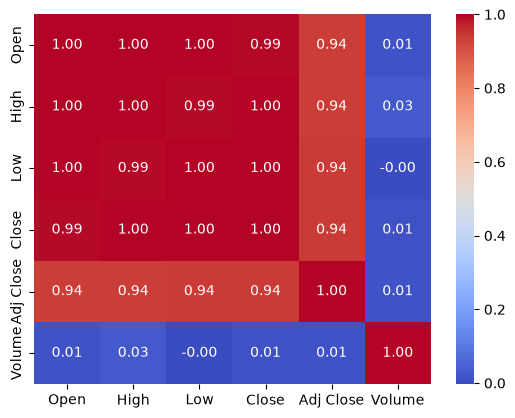

In [4]:

# dfX = pd.DataFrame(df).corr()
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

# I will use Ridge Regression

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
def print_metric(yPred, yTest, name):
    print(name)
    print("mean_absolute_error:", round(mean_absolute_error(yPred, yTest), 4))
    print("mean_squared_error:", round(mean_squared_error(yPred, yTest), 4))
    print("r2_score:", round(r2_score(yPred, yTest), 4))

ridgeModel
mean_absolute_error: 0.9517
mean_squared_error: 1.3255
r2_score: 0.8562


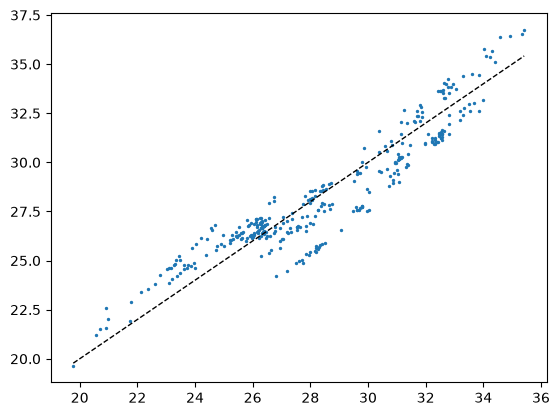

--------------------------------------------------
ridgeModel2
mean_absolute_error: 0.8063
mean_squared_error: 1.1047
r2_score: 0.8876


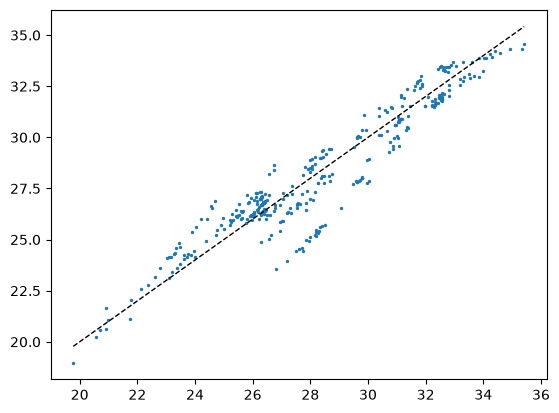

--------------------------------------------------
lassoModel
mean_absolute_error: 1.2484
mean_squared_error: 2.0673
r2_score: 0.5521


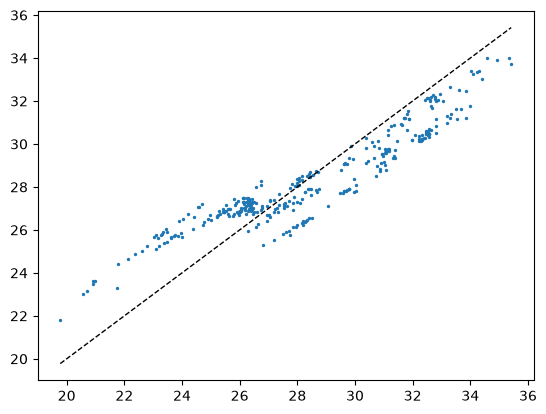

--------------------------------------------------
elasticNetModel
mean_absolute_error: 1.1228
mean_squared_error: 1.7826
r2_score: 0.6766


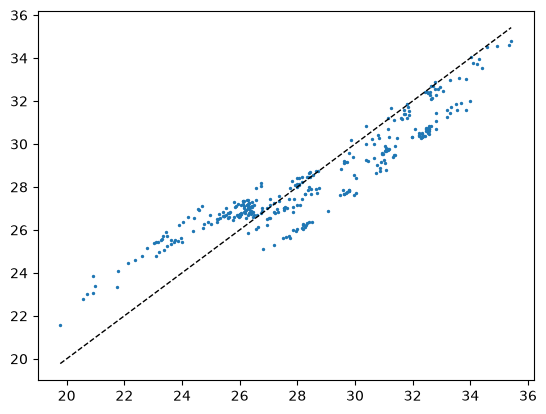

--------------------------------------------------


In [6]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import Ridge, LinearRegression, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import PredictionErrorDisplay

ridgeModel = make_pipeline(
    StandardScaler(),
    Ridge(alpha=100)
)
ridgeModel2 = make_pipeline(
    PolynomialFeatures(degree=10),
    StandardScaler(),
    Ridge()
)
lassoModel = make_pipeline(
    StandardScaler(),
    Lasso(alpha=1)
)
elasticNetModel = make_pipeline(
    StandardScaler(),
    ElasticNet()
)


all_models = {
    "ridgeModel": ridgeModel,
    "ridgeModel2": ridgeModel2,
    "lassoModel": lassoModel,
    "elasticNetModel": elasticNetModel,

}

for name, model in all_models.items():
    model.fit(XTrain, yTrain)
    yPred = model.predict(XTest)
    print_metric(yPred, yTest, name)

    plt.scatter(yTest, yPred, s=2)
    plt.plot([yTest.min(), yTest.max()],[yTest.min(), yTest.max()], 'k--', lw=1 )
    # PredictionErrorDisplay.from_estimator(model, XTest, yTest, kind="actual_vs_predicted")
    plt.show()
    print("-"*50)

    



ridgeModel
ridgeModel2
lassoModel
elasticNetModel


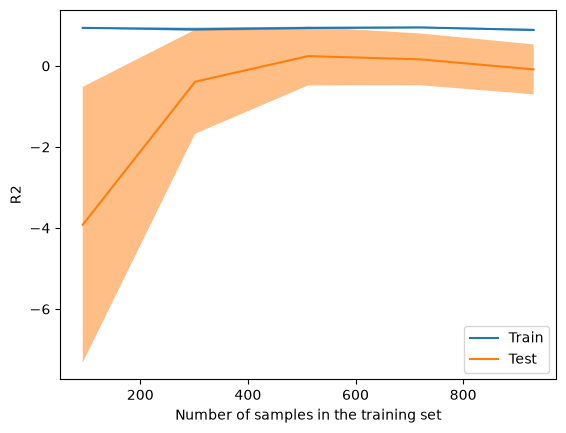

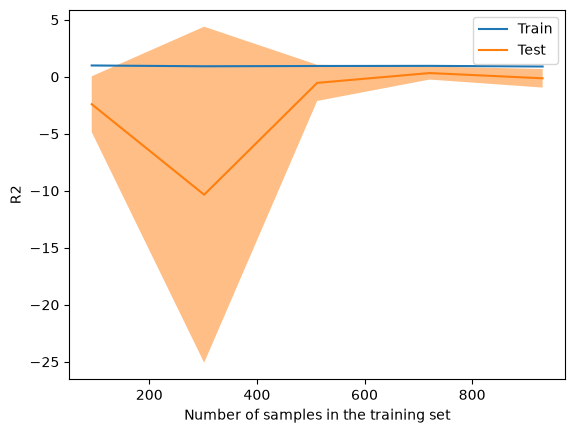

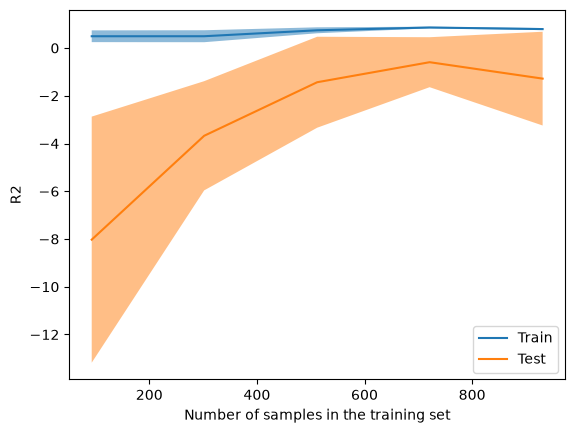

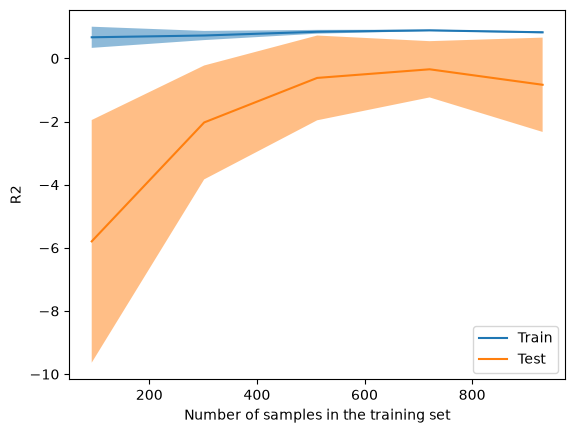

In [7]:
from sklearn.model_selection import LearningCurveDisplay
# import numpy as np

for name, model in all_models.items():
    print(name)
    LearningCurveDisplay.from_estimator(
        estimator=model,
        X=X,
        y=y,
        scoring="r2",
    )

In [8]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(ridgeModel2, file)


In [12]:
with open("model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

# print(loaded_model)
yPred = loaded_model.predict(XTest)
print_metric(yTest, yPred, "loaded model")

loaded model
mean_absolute_error: 0.8063
mean_squared_error: 1.1047
r2_score: 0.8939
